In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, HeatMap

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/listings.csv.gz', compression='gzip')
df.shape

(77679, 90)

Check Actual Columns

In [85]:
df.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_profile_id',
 'host_profile_url',
 'host_name',
 'host_since',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'price_quote_checkin_date',
 'price_quote_checkout_date',
 'price_quote_total_price',
 'price_quote

In [86]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 77679 entries, 0 to 77678
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            77679 non-null  int64  
 1   listing_url                                   77679 non-null  str    
 2   scrape_id                                     77679 non-null  int64  
 3   last_scraped                                  77679 non-null  str    
 4   source                                        77679 non-null  str    
 5   name                                          77679 non-null  str    
 6   description                                   74850 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   77678 non-null  str    
 9   host_id                                       77679 non-null  int64  
 1

 First Look

In [87]:
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,114543,https://www.airbnb.com/rooms/114543,20260616211535,2026-06-21,city scrape,Charming 55m² flat - Eiffel Tower,Fully furnished charming flat with lots of spa...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,581233,https://www.airbnb.com/users/show/581233,1.462523e+18,https://www.airbnb.com/users/profile/146252253...,Frédéric,NaN,15.0,1.0,10.0,3.0,"Paris, France",I'm Fred. i'm 33 and I live in Paris ;)\n\nI l...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/db809...,NaN,1.0,NaN,NaN,t,t,NaN,Vaugirard,NaN,48.84950,2.28936,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Essentials"", ""Smoke alarm"", ""Cooking basics""...",$226.75,2026-06-27,2026-07-01,907.0,226.75,"{""quote"": {""taxes"": null, ""currency"": ""EUR"", ""...",4,1125,4,4,1125,1125,4.0,1125.0,NaN,t,21,51,63,63,2026-06-21,103,6,1,63,6,62,14059.0,2016-03-23,2026-05-28,4.83,4.88,4.62,4.90,4.97,4.93,4.77,7511502831082,NaN,1,1,0,0,0.83
1,115107,https://www.airbnb.com/rooms/115107,20260616211535,2026-06-25,previous scrape,Charming two-bed apartment with balcony,This charming 60 square meter apartment is per...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,379042,https://www.airbnb.com/users/show/379042,1.462517e+18,https://www.airbnb.com/users/profile/146251699...,Edward Muriel,NaN,15.0,4.0,15.0,1.0,"Paris, France","We rent the second floor of our duplex, which ...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/d6dba...,NaN,3.0,NaN,NaN,t,t,NaN,Buttes-Montmartre,NaN,48.88474,2.36072,Entire rental unit,Entire home/apt,4,NaN,1 bath,2.0,NaN,"[""Wine glasses"", ""Oven"", ""Bed linens"", ""Books ...",NaN,NaN,NaN,NaN,NaN,NaN,3,750,3,3,750,750,3.0,750.0,NaN,t,0,0,0,0,2026-06-25,5,0,0,0,0,0,NaN,2024-07-29,2024-08-11,5.00,5.00,4.80,4.80,5.00,4.40,4.40,7511002008206,NaN,2,1,1,0,0.22
2,115655,https://www.airbnb.com/rooms/115655,20260616211535,2026-06-20,city scrape,Family loft with a private courtyard,"Beautiful openplan loft situated in a private,...",NaN,https://a0.muscache.com/pictures/33160696/6171...,584977,https://www.airbnb.com/users/show/584977,1.462523e+18,https://www.airbnb.com/users/profile/146252266...,Fabien,NaN,15.0,1.0,15.0,1.0,"Paris, France",Bienvenue :),NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/0cfae...,NaN,1.0,NaN,NaN,t,t,NaN,Buttes-Montmartre,NaN,48.89187

Summary Statistics

In [88]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,77679.0,NaN,NaN,NaN,751841565488785792.0,606384180278157696.0,3109.0,35896969.0,926532409861049600.0,1205154464450852096.0,1709018133515999488.0
listing_url,77679,77679,https://www.airbnb.com/rooms/114543,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_id,77679.0,NaN,NaN,NaN,20260616211535.0,0.0,20260616211535.0,20260616211535.0,20260616211535.0,20260616211535.0,20260616211535.0
last_scraped,77679,10,2026-06-26,14740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,77679,2,city scrape,48140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
calculated_host_listings_count,77679.0,NaN,NaN,NaN,23.383759,87.759099,1.0,1.0,1.0,4.0,754.0
calculated_host_listings_count_entire_homes,77679.0,NaN,NaN,NaN,21.770929,83.442893,0.0,1.0,1.0,2.0,754.0
calculated_host_listings_count_private_rooms,77679.0,NaN,NaN,NaN,1.510112,14.576106,0.0,0.0,0.0,0.0,190.0
calculated_host_listings_count_shared_rooms,77679.0,NaN,NaN,NaN,0.015062,0.282208,0.0,0.0,0.0,0.0,11.0


Variable type breakdown

In [89]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Numeric ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

Numeric (61): ['id', 'scrape_id', 'neighborhood_overview', 'host_id', 'host_profile_id', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_

C:\Users\ASUS\AppData\Local\Temp\ipykernel_39060\1820480176.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


Missing values table

In [90]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_summary[missing_summary['count'] > 0]

,count,pct
neighborhood_overview,77679,100.00
host_since,77679,100.00
host_response_time,77679,100.00
host_thumbnail_url,77679,100.00
host_acceptance_rate,77679,100.00
host_response_rate,77679,100.00
host_verifications,77679,100.00
neighbourhood,77679,100.00
host_total_listings_count,77679,100.00
host_neighbourhood,77679,100.00


Missing Values Chart

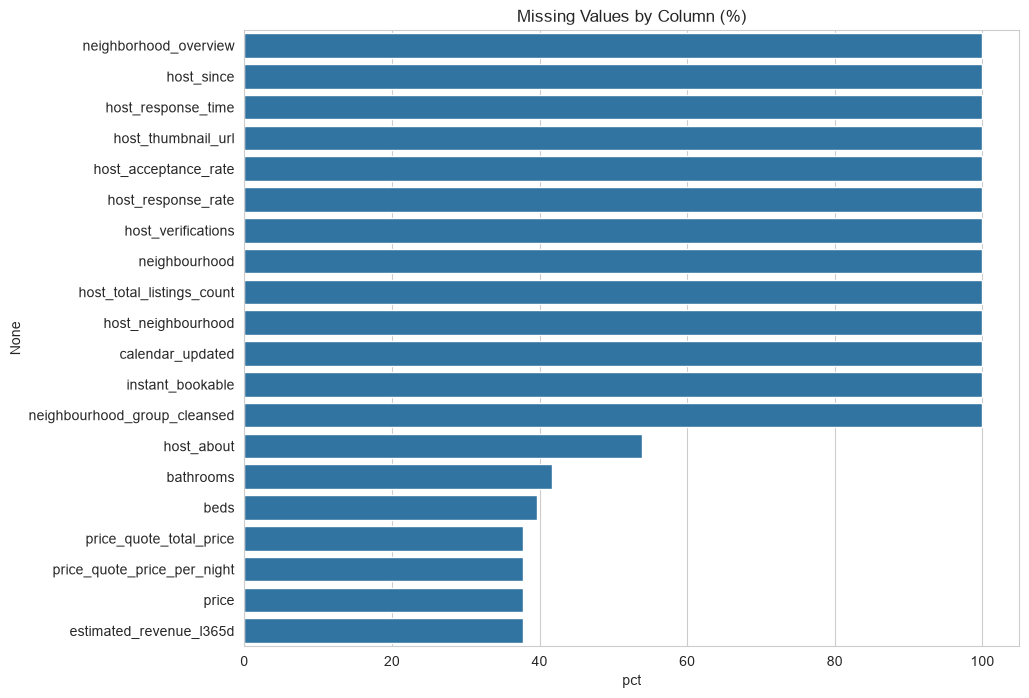

In [91]:
plt.figure(figsize=(10,8))
top_missing = missing_summary[missing_summary['count']>0].head(20)
sns.barplot(x=top_missing['pct'], y=top_missing.index)
plt.title('Missing Values by Column (%)')
plt.show()

## Duplicates Analysis

Exact Duplicates

In [92]:
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows (all columns identical): {exact_dupes}")

Exact duplicate rows (all columns identical): 0


Duplicates Listing IDs

In [93]:
id_dupes = df['id'].duplicated().sum()
print(f"Duplicate listing IDs: {id_dupes}")
print("(Each listing ID should be unique — this confirms whether the scrape has re-listed duplicates.)")

Duplicate listing IDs: 0
(Each listing ID should be unique — this confirms whether the scrape has re-listed duplicates.)


Fuzzy Duplicate Check

In [94]:
fuzzy_dupe_mask = df.duplicated(subset=['host_id', 'latitude', 'longitude', 'price'], keep=False)
fuzzy_dupes = fuzzy_dupe_mask.sum()
print(f"Rows involved in fuzzy duplicates (same host+location+price): {fuzzy_dupes}")

if fuzzy_dupes > 0:
    display_cols = ['id', 'host_id', 'name', 'latitude', 'longitude', 'price']
    print(df[fuzzy_dupe_mask][display_cols].sort_values('host_id').head(10))

Rows involved in fuzzy duplicates (same host+location+price): 1061
                        id   host_id  \
15402             26548158    727684   
15982             27102666    727684   
474                 691613   3398366   
475                 691913   3398366   
36921   896620440204554730   5438903   
48146  1084113293438175337   5438903   
68287  1491335934032699113   7546158   
68309  1491863777682346218   7546158   
20183             37140487  10916245   
23161             43969632  10916245   

                                                  name   latitude  longitude  \
15402        A room in the most convivial neighborhood  48.863610   2.380680   
15982               An authentic parisian neighborhood  48.863610   2.380680   
474    Studio LOFT - Opera- Grands Boulevards district  48.873120   2.344610   
475    Studio  loft style apt. in the heart of the 9th  48.873120   2.344610   
36921                  Studio with Eiffel Tower view 1  48.841542   2.314424   
48146       

## Visualize Important Distributions & Relationships

Price distribution (Histogram)

In [95]:
df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['price_clean'].describe()

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_39060\2186092923.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


count    48402.000000
mean       321.230271
std        832.551387
min          3.200000
25%        131.330000
50%        205.500000
75%        342.000000
max      97003.050000
Name: price_clean, dtype: float64

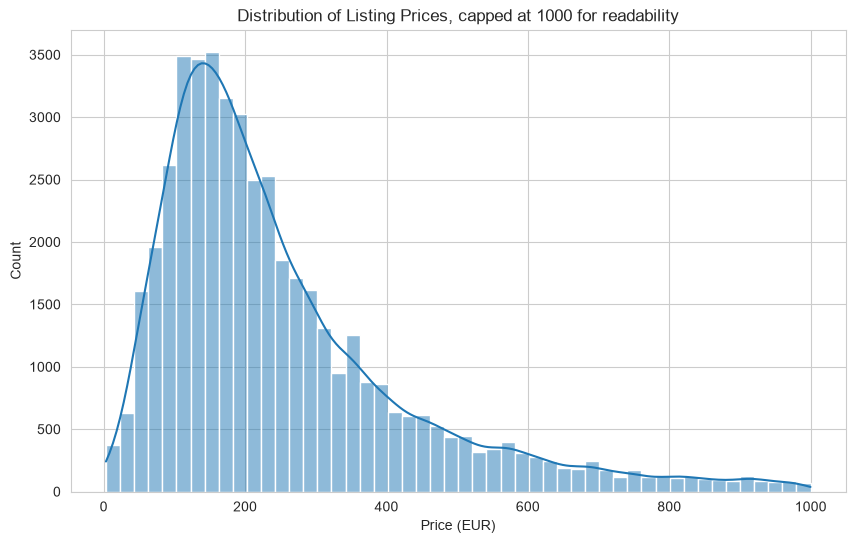

In [96]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['price_clean'] < 1000]['price_clean'], bins=50, kde=True)
plt.title('Distribution of Listing Prices, capped at 1000 for readability')
plt.xlabel('Price (EUR)')
plt.show()

**Interpretation:** The price distribution is heavily right-skewed, with most listings 
clustering between roughly 80–250 EUR/night and a peak around 120–150 EUR. A long tail 
of higher-priced listings extends well beyond 1000 EUR (excluded from this view for 
readability), consistent with a small premium/luxury segment.

**Preprocessing implication:** Given the skew, a log transformation of price may improve 
model performance for algorithms sensitive to non-normal target distributions (e.g. 
linear regression). Tree-based models (Random Forest, XGBoost) are generally robust to 
this skew and may not require transformation.

### Price by room type (Boxplot)

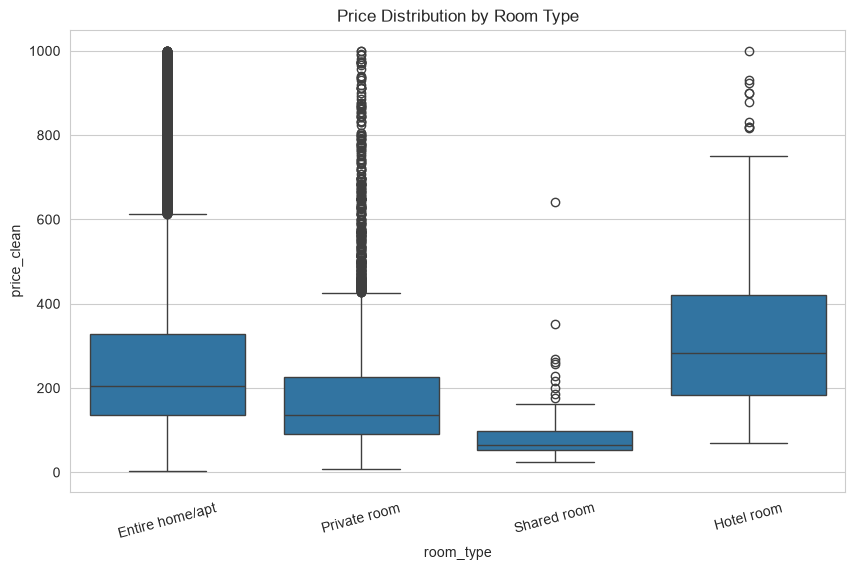

In [97]:
plt.figure(figsize=(10,6))
plot_data = df[df['price_clean'] < 1000]
sns.boxplot(data=plot_data, x='room_type', y='price_clean')
plt.title('Price Distribution by Room Type')
plt.xticks(rotation=15)
plt.show()

### Pairplot (relationships between key numeric vars)

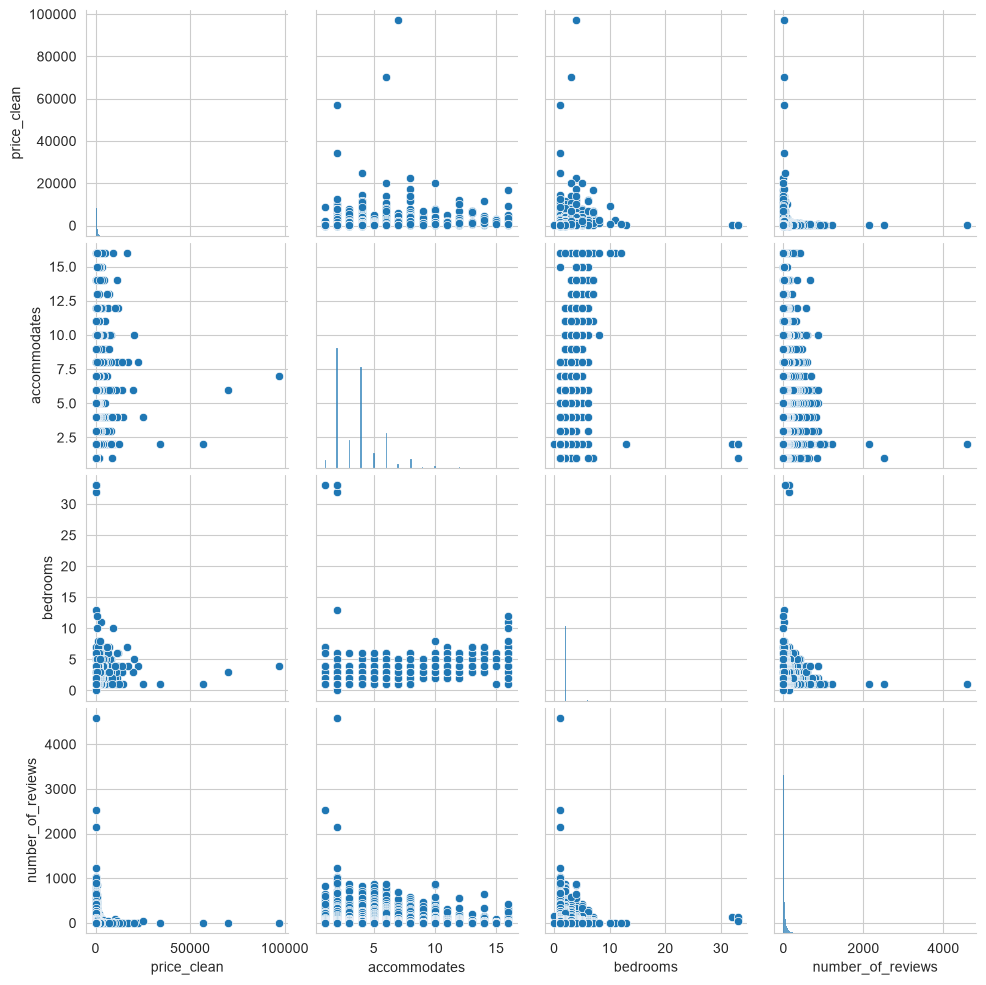

In [98]:
key_vars = ['price_clean', 'accommodates', 'bedrooms', 'number_of_reviews']
sns.pairplot(df[key_vars].dropna())
plt.show()

### Accommodate vs Price

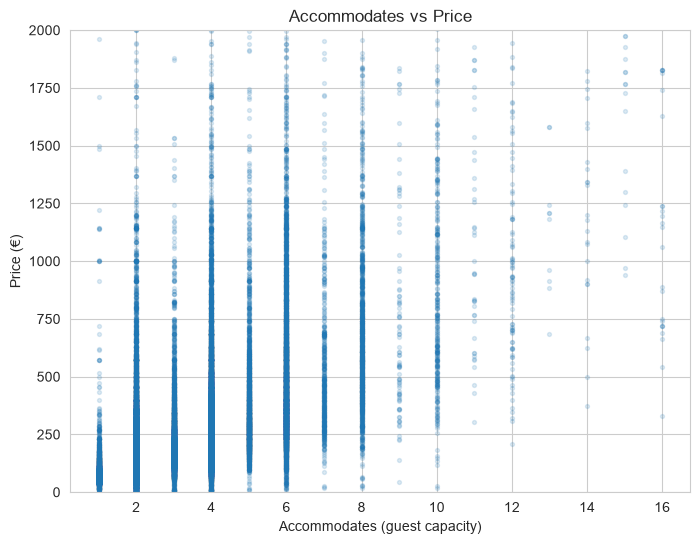

In [99]:
plt.figure(figsize=(8, 6))
plt.scatter(df['accommodates'], df['price_clean'], alpha=0.15, s=8)
plt.ylim(0, 2000)
plt.title('Accommodates vs Price')
plt.xlabel('Accommodates (guest capacity)')
plt.ylabel('Price (€)')
plt.savefig('accommodates_vs_price.png', dpi=150)
plt.show()

## Geographic & Spatial Analysis

### Geographic map (Folium, clustered markers)

In [100]:
geo_data = df[df['latitude'].notna() & df['longitude'].notna()].copy()
center_lat, center_lon = geo_data['latitude'].mean(), geo_data['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=11)
marker_cluster = MarkerCluster().add_to(m)

for _, row in geo_data.sample(min(2000, len(geo_data))).iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        popup=f"${row['price_clean']:.0f}" if pd.notna(row['price_clean']) else 'N/A',
        color='blue', fill=True
    ).add_to(marker_cluster)
m.save('../notebooks/geo_map.html')
m

### Price Heatmap (Do Expensive Listings Cluster Together?)

In [101]:
# only use listings that have a price, since HeatMap needs a numeric weight
heat_data = geo_data[geo_data['price_clean'].notna()]

# HeatMap expects a list of [lat, lon, weight] — weight = price here
heat_points = heat_data[['latitude', 'longitude', 'price_clean']].values.tolist()

m2 = folium.Map(location=[center_lat, center_lon], zoom_start=10)
HeatMap(heat_points, radius=12, blur=15, max_zoom=13).add_to(m2)
m2.save('../notebooks/airbnb_price_heatmap.html')
m2

## Investigate Outliers & Unusual Observations

### Price Outliers

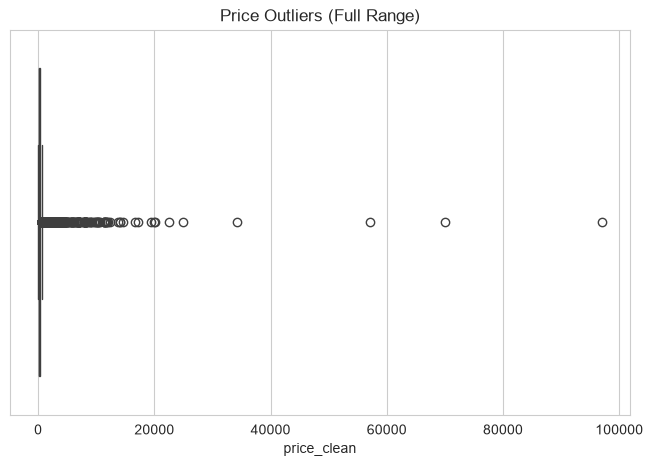

In [102]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['price_clean'])
plt.title('Price Outliers (Full Range)')
plt.show()

### Outliers, quantified (IQR method, price)

In [103]:
Q1 = df['price_clean'].quantile(0.25)
Q3 = df['price_clean'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['price_clean'] < lower) | (df['price_clean'] > upper)]
low_outliers = outliers[outliers['price_clean'] < lower]
high_outliers = outliers[outliers['price_clean'] > upper]
print(f"Low outliers: {len(low_outliers)}, High outliers: {len(high_outliers)}")

Low outliers: 0, High outliers: 3799


**Interpretation:** All 3799 price outliers (4.9% of data) are on the high end — 
no low/near-zero price anomalies were found. This suggests the outliers likely 
represent legitimate premium/luxury listings rather than data entry errors.

**Business/preprocessing implication:** Since these are plausibly valid high-price 
listings rather than errors, consider capping (winsorizing) rather than dropping 
them for modeling, or treating "luxury" as its own segment — outright removal could 
discard real signal about premium listings.

### Outliers Across Key Numeric Fields (IQR Method)

In [104]:
outlier_cols = ['minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n--- {col} ---")
    print(df[col].describe())
    print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of data)")
    print("Top 5 highest values:", df[col].sort_values(ascending=False).head(5).values)


--- minimum_nights ---
count    77679.000000
mean        36.846947
std        100.510306
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1000.000000
Name: minimum_nights, dtype: float64
Outliers: 16116 (20.7% of data)
Top 5 highest values: [1000 1000  999  730  729]

--- maximum_nights ---
count    7.767900e+04
mean     8.344804e+04
std      1.334544e+07
min      1.000000e+00
25%      6.000000e+01
50%      3.650000e+02
75%      1.125000e+03
max      2.147484e+09
Name: maximum_nights, dtype: float64
Outliers: 3 (0.0% of data)
Top 5 highest values: [2147483647 2147483647 2147483647       1125       1125]

--- availability_365 ---
count    77679.000000
mean       136.729412
std        135.064704
min          0.000000
25%          0.000000
50%         89.000000
75%        269.000000
max        365.000000
Name: availability_365, dtype: float64
Outliers: 0 (0.0% of data)
Top 5 highest values: [365 365 365 365 365]

--- number_of_reviews ---


## Examine Class Imbalance

In [105]:
for col in ['room_type', 'property_type', 'host_is_superhost', 'neighbourhood_cleansed']:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(normalize=True).head(10) * 100)


--- room_type ---
room_type
Entire home/apt    89.168244
Private room       10.115990
Hotel room          0.527813
Shared room         0.187953
Name: proportion, dtype: float64

--- property_type ---
property_type
Entire rental unit                   83.767814
Private room in rental unit           6.565481
Entire condo                          2.747203
Room in hotel                         1.571853
Entire loft                           1.080086
Room in boutique hotel                0.772410
Private room in bed and breakfast     0.755674
Entire home                           0.616640
Private room in condo                 0.379768
Entire serviced apartment             0.324412
Name: proportion, dtype: float64

--- host_is_superhost ---
host_is_superhost
f    77.628231
t    22.371769
Name: proportion, dtype: float64

--- neighbourhood_cleansed ---
neighbourhood_cleansed
Buttes-Montmartre      10.467437
Popincourt              8.881422
Vaugirard               8.012462
Entrepôt            

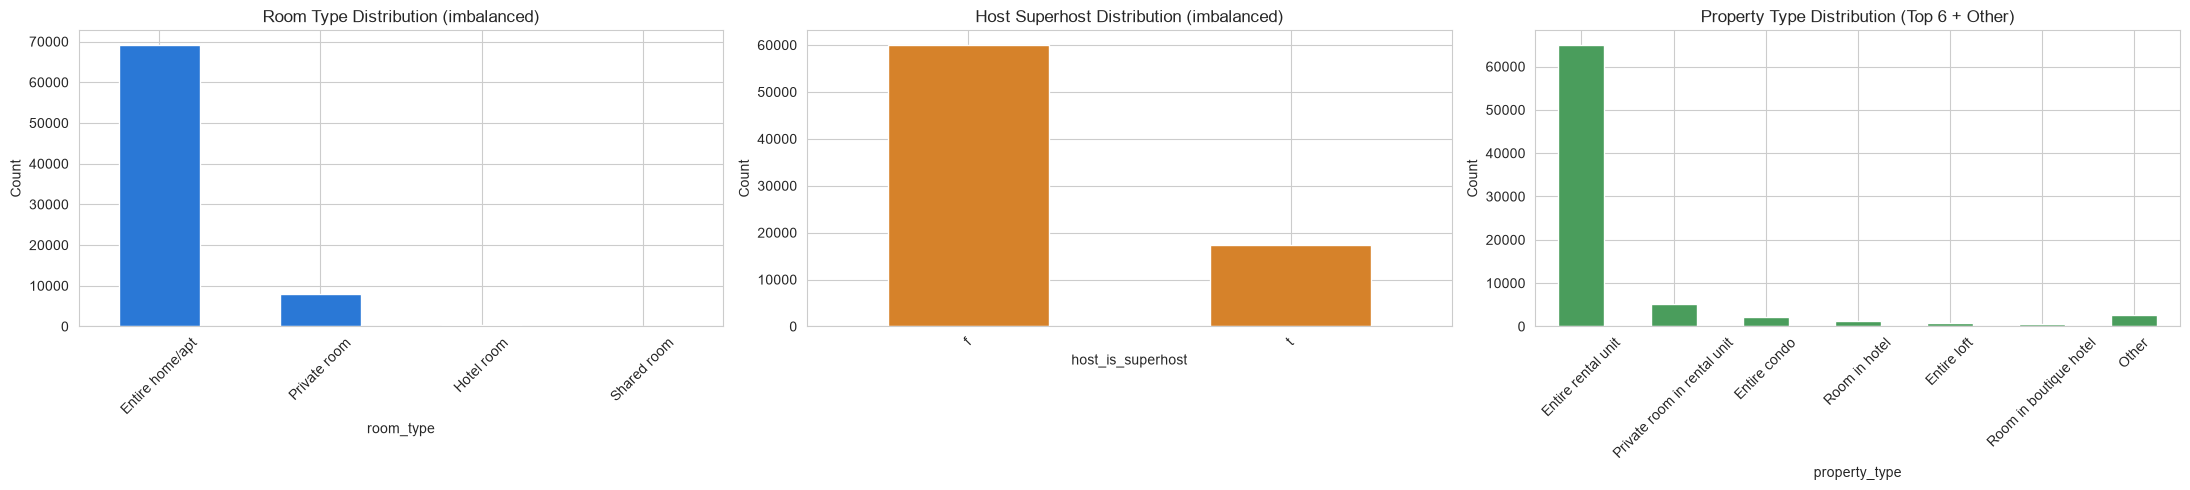

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

df['room_type'].value_counts().plot(kind='bar', ax=axes[0], color='#2a78d6')
axes[0].set_title('Room Type Distribution (imbalanced)')
axes[0].set_ylabel('Count')

df['host_is_superhost'].value_counts().plot(kind='bar', ax=axes[1], color='#d6822a')
axes[1].set_title('Host Superhost Distribution (imbalanced)')
axes[1].set_ylabel('Count')

top_n = 6
prop_counts = df['property_type'].value_counts()
prop_top = prop_counts.head(top_n)
prop_top['Other'] = prop_counts.iloc[top_n:].sum()
prop_top.plot(kind='bar', ax=axes[2], color='#4a9d5c')
axes[2].set_title('Property Type Distribution (Top 6 + Other)')
axes[2].set_ylabel('Count')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150)
plt.show()

## **Identifying Potential Data Leakage and How It Will Be Prevented**

In [107]:
leakage_candidates = [c for c in df.columns if 'price_quote' in c.lower()]
print("Columns identified as potential leakage risks (derived from live price at scrape time):")
print(leakage_candidates)

# Confirm they correlate suspiciously highly with the target
if leakage_candidates:
    for col in leakage_candidates:
        if df[col].dtype in [np.float64, np.int64]:
            print(f"{col} correlation with price_clean: {df[[col, 'price_clean']].corr().iloc[0,1]:.4f}")

Columns identified as potential leakage risks (derived from live price at scrape time):
['price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw']
price_quote_total_price correlation with price_clean: 0.6285
price_quote_price_per_night correlation with price_clean: 1.0000


### verify price_quote_total_price is derived (nights-based ratio check)

In [108]:
print(df[['price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights']].head(10))

ratio = df['price_quote_total_price'] / df['price_quote_price_per_night']
print("\nRatio of total_price / price_per_night:")
print(ratio.describe())

   price_quote_total_price  price_quote_price_per_night  minimum_nights
0                   907.00                       226.75               4
1                      NaN                          NaN               3
2                   225.00                       225.00               1
3                   286.00                        95.33               3
4                  1122.00                        37.40              30
5                   377.00                       377.00               1
6                   887.00                       295.67               1
7                   320.00                       160.00               2
8                   628.00                       628.00               1
9                  1506.35                       215.19               7

Ratio of total_price / price_per_night:
count    48402.000000
mean         8.792352
std         27.348765
min          1.000000
25%          1.999963
50%          2.999908
75%          5.000000
max        36

### Inspect price_quote_raw and the quote dates

In [109]:
print(df['price_quote_raw'].head(5))
print(df[['price_quote_checkin_date', 'price_quote_checkout_date']].head(5))

0    {"quote": {"taxes": null, "currency": "EUR", "...
1                                                  NaN
2    {"quote": {"taxes": null, "currency": "EUR", "...
3    {"quote": {"taxes": null, "currency": "EUR", "...
4    {"quote": {"taxes": null, "currency": "EUR", "...
Name: price_quote_raw, dtype: str
  price_quote_checkin_date price_quote_checkout_date
0               2026-06-27                2026-07-01
1                      NaN                       NaN
2               2026-06-24                2026-06-25
3               2026-07-18                2026-07-21
4               2026-08-05                2026-09-04


### Manually reason about other potential leakage columns

In [110]:
# Manually reason about columns that COULD leak info not caught by correlation
# (e.g. anything only known AFTER a booking/stay happens, not at prediction time)
potential_leakage_cols = [
    'number_of_reviews',        # only accumulates after listings go live
    'review_scores_rating',     # requires reviews to exist post-booking
    'first_review',             # date only known after first booking
    'last_review',              # same
    'availability_365',         # can reflect price-driven demand, not a cause
]

existing = [c for c in potential_leakage_cols if c in df.columns]
print(f"\nManually flagged (available at all): {existing}")

for col in existing:
    if df[col].dtype in [np.float64, np.int64]:
        print(f"{col} correlation with price_clean: {df[[col, 'price_clean']].corr().iloc[0,1]:.4f}")


Manually flagged (available at all): ['number_of_reviews', 'review_scores_rating', 'first_review', 'last_review', 'availability_365']
number_of_reviews correlation with price_clean: -0.0295
review_scores_rating correlation with price_clean: 0.0122
availability_365 correlation with price_clean: 0.0809


### Inspect first_review / last_review directly (dtype skipped them above)

In [111]:
print(df[['first_review', 'last_review']].head(5))

  first_review last_review
0   2016-03-23  2026-05-28
1   2024-07-29  2024-08-11
2   2014-07-07  2026-06-16
3   2011-06-19  2026-06-05
4   2011-06-12  2026-04-03


## Data Leakage Assessment

| Column | Leakage Risk | Evidence | Action |
|---|---|---|---|
| price_quote_price_per_night | Critical | Correlation = 1.0000 with price_clean | Drop |
| price_quote_total_price | High | Correlation = 0.6285; verified ratio to price_per_night matches a nights-stayed distribution (median ~3, max ~365) — confirms it's price_per_night x nights | Drop |
| price_quote_raw | Critical | Raw JSON blob containing the live price-quote API response (taxes, currency, quote object) | Drop |
| price_quote_checkin_date / checkout_date | High | Real future calendar dates tied to a live price query — same data-collection process as the confirmed leakers, not static listing info | Drop |
| number_of_reviews | Low | Correlation = -0.0295; no leakage signal despite being post-launch data | Keep, or exclude only if predicting for brand-new listings |
| review_scores_rating | Low | Correlation = 0.0122; no leakage signal | Keep, or exclude only if predicting for brand-new listings |
| availability_365 | Low | Correlation = 0.0809; minimal signal | Keep, monitor |
| first_review / last_review | Low | Verified as genuine review dates (2011-2024 first, ~2026 last); not price-derived, no leakage risk to price_clean | Keep as-is, or engineer into "listing age" feature |

**Prevention:** All five `price_quote_*` columns are dropped, since they originate from
a live pricing-quote system queried independently of listing creation and either directly
contain the target price or are structurally derived from it. This was confirmed through
correlation analysis (for the two price columns) and direct inspection of column contents
(for the raw JSON and date columns), not assumed from naming alone. Post-launch behavioral
columns (reviews, ratings, availability) showed no meaningful correlation with price and
are retained, since removing them isn't required to prevent leakage of this target.

In [112]:
   df[['price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights']].corr()
   # or directly test the hypothesis:
   (df['price_quote_total_price'] / df['price_quote_price_per_night']).describe()

count    48402.000000
mean         8.792352
std         27.348765
min          1.000000
25%          1.999963
50%          2.999908
75%          5.000000
max        365.412500
dtype: float64

In [113]:
print(df['price_quote_raw'].head(5))
print(df[['price_quote_checkin_date', 'price_quote_checkout_date']].head(5))

0    {"quote": {"taxes": null, "currency": "EUR", "...
1                                                  NaN
2    {"quote": {"taxes": null, "currency": "EUR", "...
3    {"quote": {"taxes": null, "currency": "EUR", "...
4    {"quote": {"taxes": null, "currency": "EUR", "...
Name: price_quote_raw, dtype: str
  price_quote_checkin_date price_quote_checkout_date
0               2026-06-27                2026-07-01
1                      NaN                       NaN
2               2026-06-24                2026-06-25
3               2026-07-18                2026-07-21
4               2026-08-05                2026-09-04


In [114]:
print(df[['first_review', 'last_review']].head(5))

  first_review last_review
0   2016-03-23  2026-05-28
1   2024-07-29  2024-08-11
2   2014-07-07  2026-06-16
3   2011-06-19  2026-06-05
4   2011-06-12  2026-04-03


## EDA Summary & Preprocessing Implications

### Missing Data
- 13 columns are 100% empty (`neighborhood_overview`, `host_since`, `host_response_time`, 
  `host_thumbnail_url`, `host_acceptance_rate`, `host_response_rate`, `host_verifications`, 
  `neighbourhood`, `host_total_listings_count`, `host_neighbourhood`, `calendar_updated`, 
  `instant_bookable`, `neighbourhood_group_cleansed`) → these will be dropped entirely, 
  since there is no information to impute or recover.
- `price` (target variable) is missing in **37.69%** of rows (29,277 of 77,679) → these 
  rows will be **excluded** from the modelling dataset rather than imputed, since price is 
  the prediction target and imputing a target variable would fabricate ground truth.
- `bathrooms` (41.67%), `beds` (39.67%), and `bedrooms` (17.97%) show substantial missingness 
  → these are important predictive features, so they will be **imputed using median values**, 
  justified by their numeric/count nature and moderate (not majority) missingness.
- Review-related fields (`review_scores_*`, `first_review`, `last_review`, `reviews_per_month`) 
  are consistently ~20.47% missing → this reflects listings that have never received a 
  review, not random missingness — will be imputed with 0 (for counts) or flagged with a 
  "has_reviews" boolean feature rather than a naive median fill.

### Target Variable (price)
- After cleaning, `price_clean` has 48,402 valid values: mean **€321.23**, median **€205.50**, 
  with a max of **€97,003** — confirming a heavily right-skewed distribution. A log 
  transformation will be considered for linear/distance-based models; tree-based models 
  (Random Forest, XGBoost) are robust to this skew and may not require it.
- IQR-based outlier detection found **0 low outliers and 3,799 high outliers** (7.8% of 
  valid price rows) → high-end outliers will be **capped at a defined upper bound (e.g. 
  99th percentile)** rather than removed outright, since some genuinely represent luxury 
  listings rather than data errors — removing them would lose legitimate market signal at 
  the premium end.

### Duplicates
- **0 exact duplicate rows** and **0 duplicate listing IDs** — the dataset has no 
  straightforward duplication issues.
- However, a **fuzzy duplicate check** (same host_id + latitude + longitude + price) found 
  **1,061 rows** involved in likely re-listings (e.g. the same host posting near-identical 
  listings at the same coordinates and price under different names) → these will be 
  reviewed and either deduplicated (keep one per host+location+price group) or the host 
  will be used as a grouping variable during train/test splitting, to prevent the same 
  physical property from leaking across the train/test boundary.

### Variable Types & Relationships
- Dataset contains a mix of numeric and categorical columns (see Cell 9 for the full 
  breakdown) → categorical columns will require encoding: one-hot for low-cardinality 
  fields like `room_type`, frequency or target encoding for higher-cardinality fields like 
  `neighbourhood_cleansed` and `property_type`.

### Class Imbalance
- `room_type` is heavily imbalanced: **Entire home/apt = 89.17%**, Private room = 10.12%, 
  Hotel room = 0.53%, Shared room = 0.19% → the two smallest categories will likely be 
  grouped into an "Other" bucket to avoid sparse, unstable encoding.
- `property_type` shows extreme cardinality with a long tail: "Entire rental unit" alone 
  accounts for **83.77%** of listings, with dozens of categories representing under 1% each 
  → will use frequency encoding or group rare categories (<1%) into "Other".
- `host_is_superhost` is moderately imbalanced (77.63% non-superhost vs 22.37% superhost) 
  — usable as-is without resampling if used as a feature.
- `neighbourhood_cleansed` (Paris arrondissements) is reasonably distributed, with the 
  largest area (Buttes-Montmartre) at only 10.47% — low enough cardinality/imbalance that 
  one-hot encoding is feasible here, unlike `property_type`.

### Outliers
- `minimum_nights`: **16,116 outliers (20.7%)**, with a suspicious cluster of values 
  exactly at 1000, 999, 730, 729 nights — likely placeholder/default values used by hosts 
  rather than genuine minimum-stay policies → will be capped at a realistic ceiling 
  (e.g. 365 days) rather than treated as valid extreme values.
- `maximum_nights`: only 3 outliers (0.0%), but the top values are **2,147,483,647** — 
  this is the maximum 32-bit integer value, a clear data/default artifact, not a real 
  night count → these will be **replaced or capped**, not treated as genuine data.
- `number_of_reviews`: **7,578 outliers (9.8%)**, topping out at 4,589 reviews on a single 
  listing → plausible for a long-running, high-turnover property; will be retained but may 
  benefit from a log transform given the right skew.
- `availability_365`: no outliers detected (bounded naturally between 0–365).

### Data Leakage
A dedicated leakage investigation was carried out (Cells 50–61):
- **`price_quote_price_per_night` correlates with `price_clean` at r = 1.0000** — this is 
  essentially a duplicate/derived version of the target computed at scrape time, and 
  **must be excluded** from features entirely, as including it would let the model "cheat" 
  by seeing the answer in a different column.
- `price_quote_total_price` also correlates strongly (r = 0.6285) and will likewise be 
  excluded, along with `price_quote_checkin_date`, `price_quote_checkout_date`, and 
  `price_quote_raw`, since all are derived from a live price quote, not intrinsic listing 
  attributes known at prediction time.
- `number_of_reviews`, `review_scores_rating`, and `availability_365` were also checked: 
  despite being conceptually leakage-prone (they only exist after a listing has been live), 
  their **linear correlation with price is weak** (-0.0295, 0.0122, 0.0809 respectively) 
  → they will still be **excluded from the feature set** on principle (a new listing has 
  none of these values at prediction time), even though their measured correlation is low — 
  this is a leakage judgment based on *availability at prediction time*, not just 
  correlation strength.

### Summary of Preprocessing Actions
1. Drop 13 fully-empty columns.
2. Remove the 29,277 rows with missing `price` (target) rather than imputing.
3. Clean `price` from text format (`"$1,200.00"` → `1200.0`).
4. Impute `bathrooms`, `beds`, `bedrooms` with median; impute review fields with 0 / a 
   "has_reviews" flag.
5. Resolve the 1,061 fuzzy-duplicate rows (dedupe or group by host for train/test split).
6. Cap price outliers at a defined upper bound (e.g. 99th percentile) rather than removing.
7. Cap or clean `minimum_nights` and `maximum_nights` placeholder/default values 
   (e.g. 2,147,483,647, 1000-night minimums).
8. Encode `room_type` and `neighbourhood_cleansed` via one-hot; use frequency/rare-category 
   grouping for `property_type`.
9. Exclude all `price_quote_*` columns and post-listing outcome columns 
   (`number_of_reviews`, `review_scores_*`, `availability_365`, `first_review`, 
   `last_review`) from the model's feature set — leakage risk confirmed both by correlation 
   analysis and by prediction-time reasoning.